# Earthquake Magnitude Analysis — EDA

**Name:**  
**Dataset:** USGS Earthquake Events (2023–2024, magnitude ≥ 1.5)  
**Dependent Variable:** `mag` (earthquake magnitude, quantitative)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/earthquakes.csv')
print(df.shape)
df.head()

(20000, 16)


,id,longitude,latitude,depth,mag,magType,nst,gap,dmin,rms,place,type,status,year,month,region
0,ak0231nosyg,-145.1789,63.2970,2.80,1.70,ml,NaN,NaN,NaN,0.37,"31 km NE of Paxson, Alaska",earthquake,reviewed,2023,1,Alaska
1,ak0231nqjkb,-151.8545,59.7316,60.00,1.80,ml,NaN,NaN,NaN,0.35,"5 km SSW of Anchor Point, Alaska",earthquake,reviewed,2023,1,Alaska
2,us7000j5a1,178.5218,52.0999,82.77,3.10,ml,14.0,139.0,0.87000,0.18,"Rat Islands, Aleutian Islands, Alaska",earthquake,reviewed,2023,1,"Aleutian Islands, Alaska"
3,ci40152471,-118.7125,34.4015,6.66,1.93,ml,52.0,33.0,0.04754,0.25,"8km ESE of Piru, CA",earthquake,reviewed,2023,1,CA
4,ak0231o4ull,-150.7628,62.9888,114.00,1.90,ml,NaN,NaN,NaN,0.36,"54 km N of Petersville, Alaska",earthquake,reviewed,2023,1,Alaska


## 1. Basic Summary Statistics

In [2]:
df.describe()

,longitude,latitude,depth,mag,nst,gap,dmin,rms,year,month
count,20000.000000,20000.000000,20000.000000,20000.000000,13738.000000,13738.000000,12131.000000,20000.000000,20000.0,20000.000000
mean,-96.561707,35.623712,41.807313,2.624727,33.410686,120.272049,1.348177,0.424502,2023.0,2.235150
std,97.429356,24.933717,79.071809,1.126709,30.697517,67.511610,3.045248,0.273449,0.0,0.971134
min,-179.995000,-65.425400,-3.500000,1.500000,2.000000,8.000000,0.000000,0.000000,2023.0,1.000000
25%,-155.418671,19.250291,6.700000,1.750000,15.000000,66.000000,0.049905,0.166125,2023.0,1.000000
50%,-139.184300,38.183400,11.710000,2.100000,24.000000,104.000000,0.244000,0.420000,2023.0,2.000000
75%,-87.927625,54.765083,42.224000,3.400000,41.000000,166.000000,1.470000,0.620000,2023.0,3.000000
max,179.999400,86.173800,681.238000,7.800000,345.000000,350.000000,41.407000,2.900000,2023.0,4.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         20000 non-null  str    
 1   longitude  20000 non-null  float64
 2   latitude   20000 non-null  float64
 3   depth      20000 non-null  float64
 4   mag        20000 non-null  float64
 5   magType    20000 non-null  str    
 6   nst        13738 non-null  float64
 7   gap        13738 non-null  float64
 8   dmin       12131 non-null  float64
 9   rms        20000 non-null  float64
 10  place      20000 non-null  str    
 11  type       20000 non-null  str    
 12  status     20000 non-null  str    
 13  year       20000 non-null  int64  
 14  month      20000 non-null  int64  
 15  region     20000 non-null  str    
dtypes: float64(8), int64(2), str(6)
memory usage: 2.4 MB


In [4]:
print('Missing values per column:')
df.isnull().sum().sort_values(ascending=False)

Missing values per column:


dmin         7869
nst          6262
gap          6262
id              0
depth           0
latitude        0
magType         0
longitude       0
mag             0
rms             0
place           0
type            0
status          0
year            0
month           0
region          0
dtype: int64

## 2. Distribution of Dependent Variable (mag)

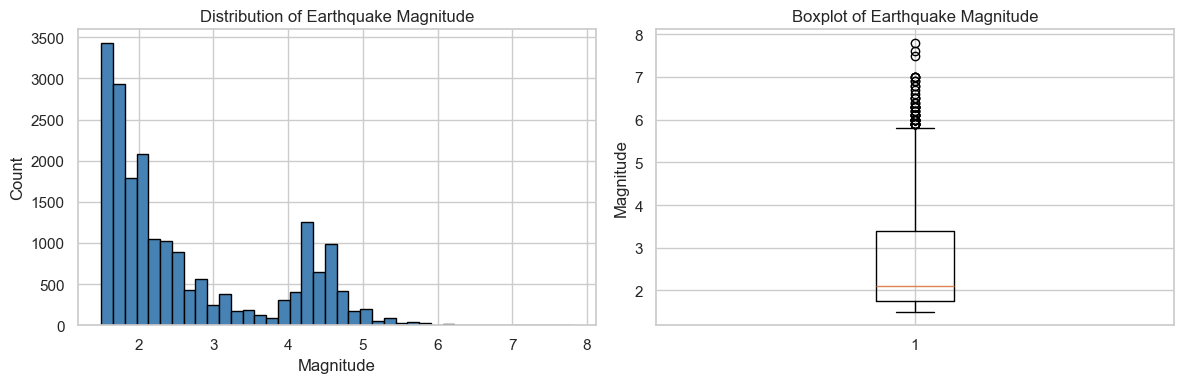

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['mag'].dropna(), bins=40, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution of Earthquake Magnitude')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['mag'].dropna())
axes[1].set_title('Boxplot of Earthquake Magnitude')
axes[1].set_ylabel('Magnitude')

plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/mag_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Categorical Variables vs. Magnitude

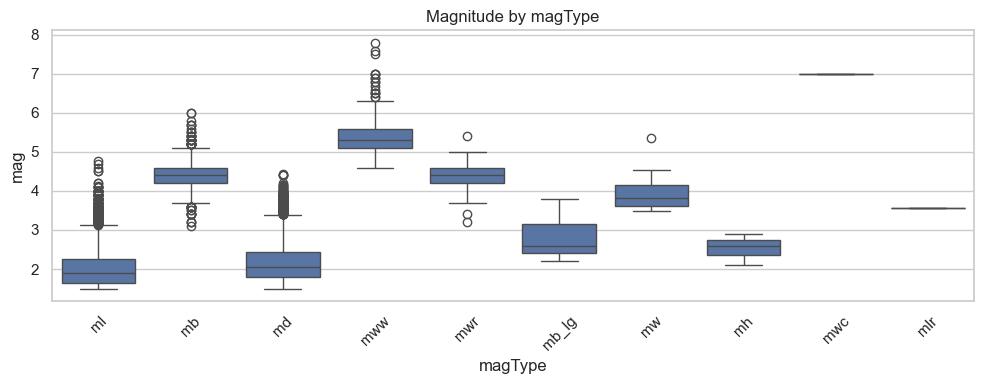

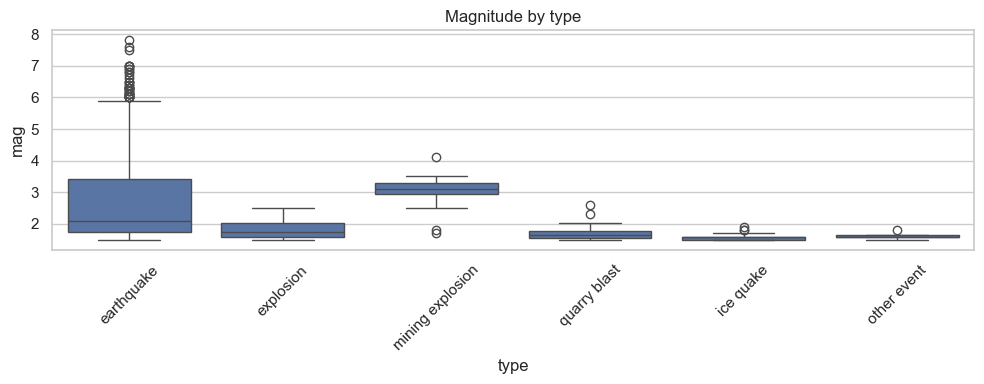

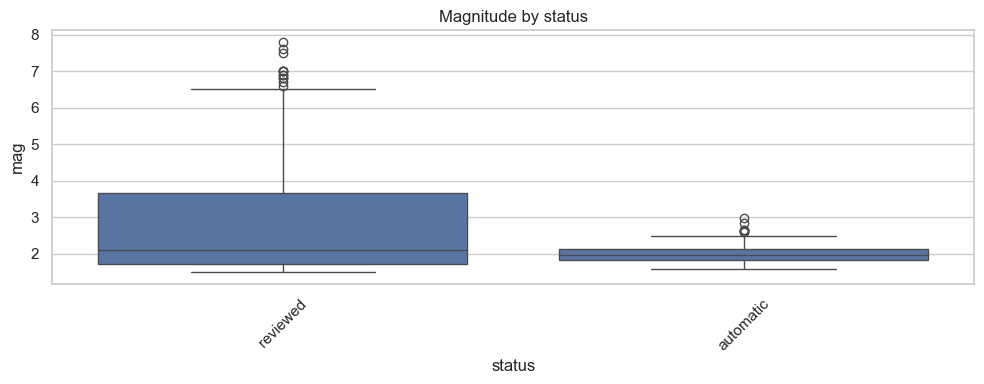

In [6]:
cat_cols = ['magType', 'type', 'status']

for col in cat_cols:
    top_cats = df[col].value_counts().nlargest(10).index
    subset = df[df[col].isin(top_cats)]

    plt.figure(figsize=(10, 4))
    sns.boxplot(data=subset, x=col, y='mag', order=top_cats)
    plt.title(f'Magnitude by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'../results/{col}_vs_mag.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Quantitative Variables vs. Magnitude (Scatter Plots)

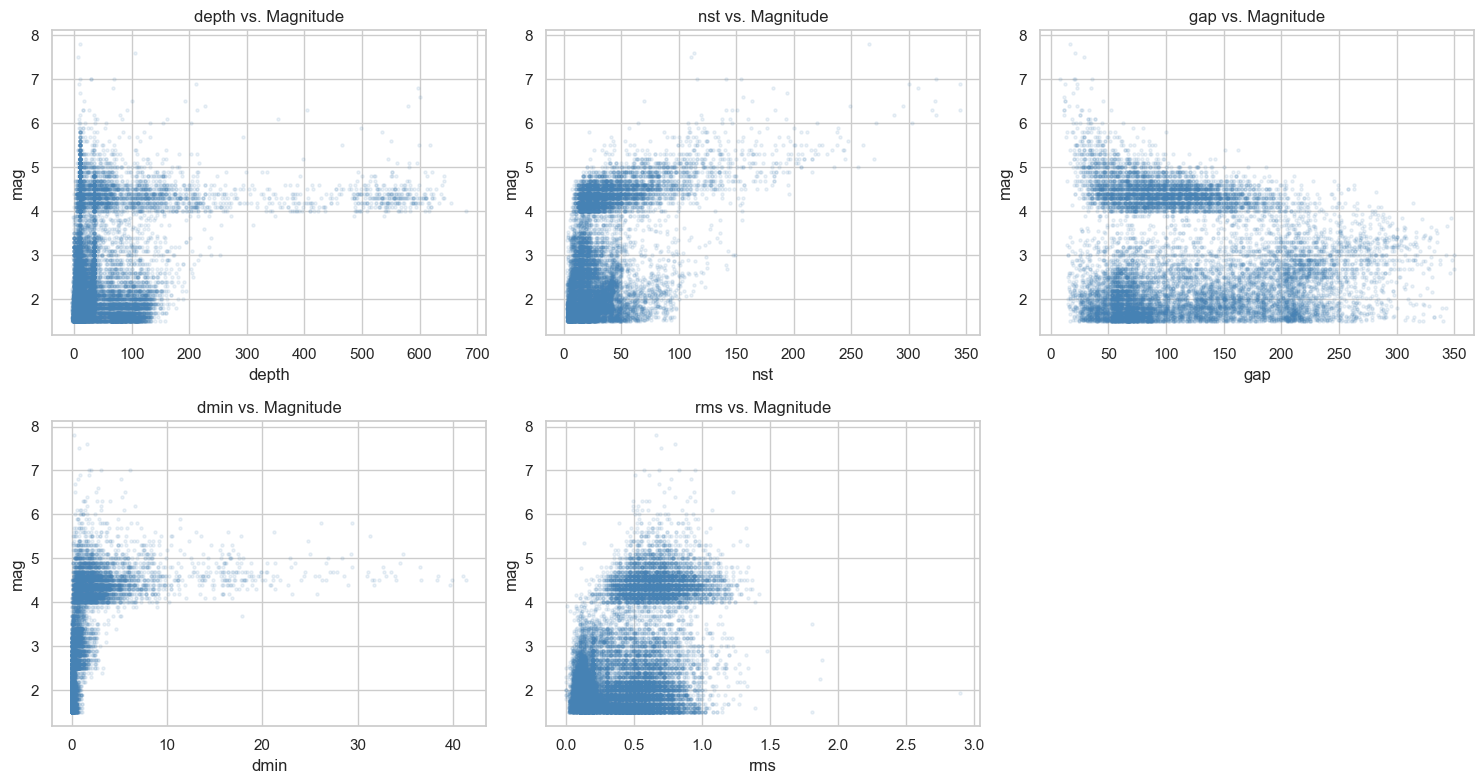

In [7]:
quant_cols = ['depth', 'nst', 'gap', 'dmin', 'rms']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    axes[i].scatter(df[col], df['mag'], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('mag')
    axes[i].set_title(f'{col} vs. Magnitude')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../results/quant_vs_mag.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

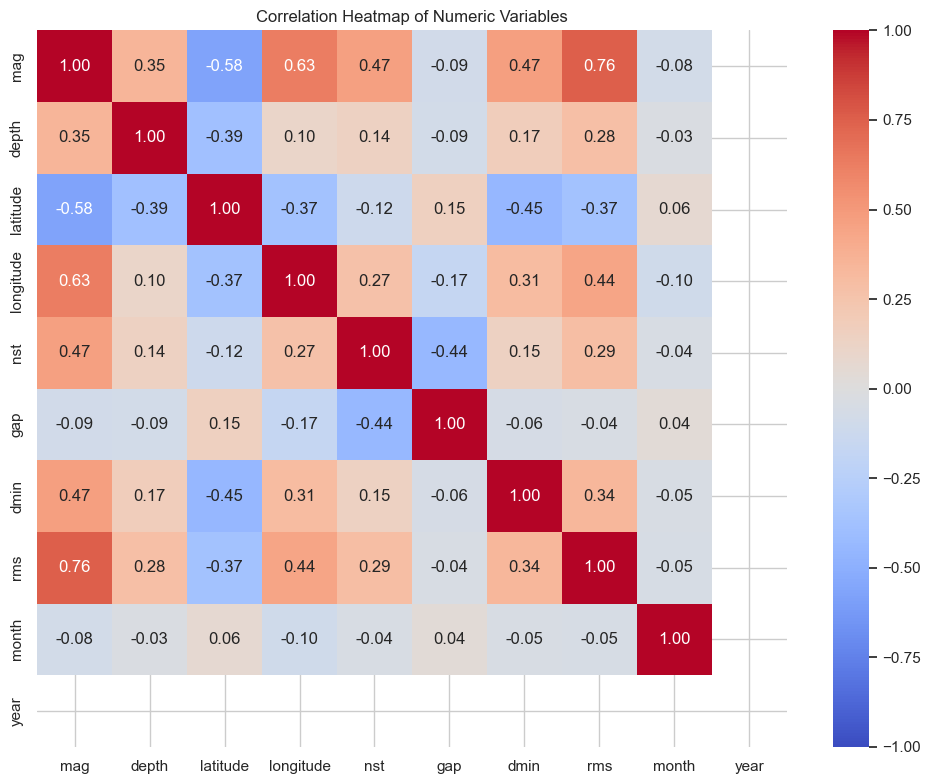

In [8]:
num_df = df[['mag', 'depth', 'latitude', 'longitude', 'nst', 'gap', 'dmin', 'rms', 'month', 'year']].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Geographic Distribution

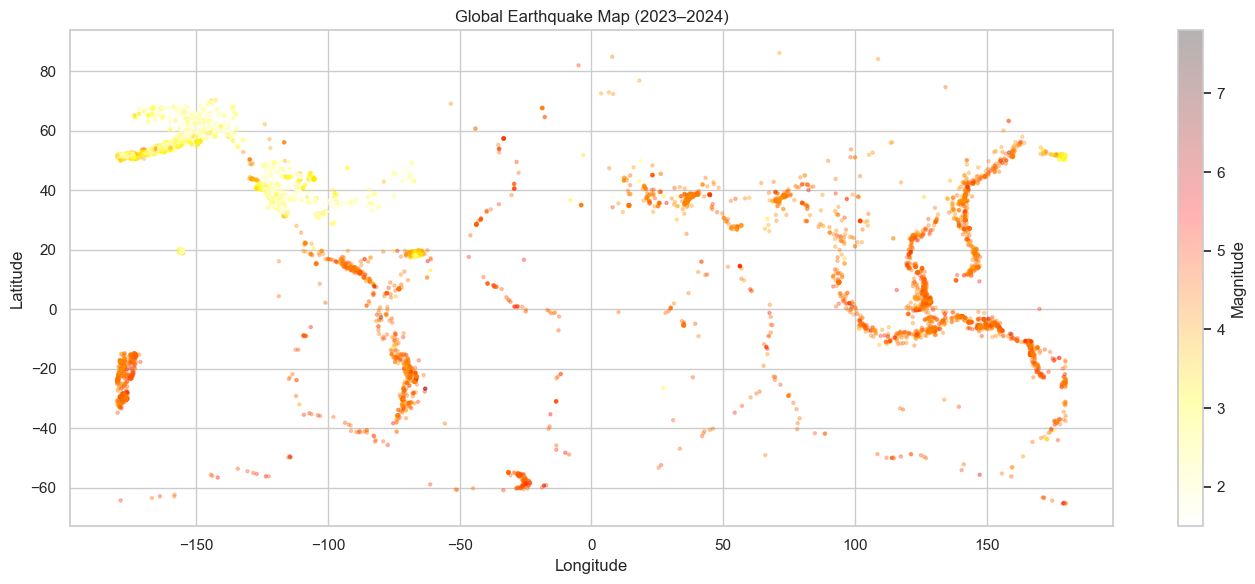

In [9]:
plt.figure(figsize=(14, 6))
scatter = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['mag'], cmap='hot_r', alpha=0.3, s=5
)
plt.colorbar(scatter, label='Magnitude')
plt.title('Global Earthquake Map (2023–2024)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('../results/earthquake_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Earthquakes per Month

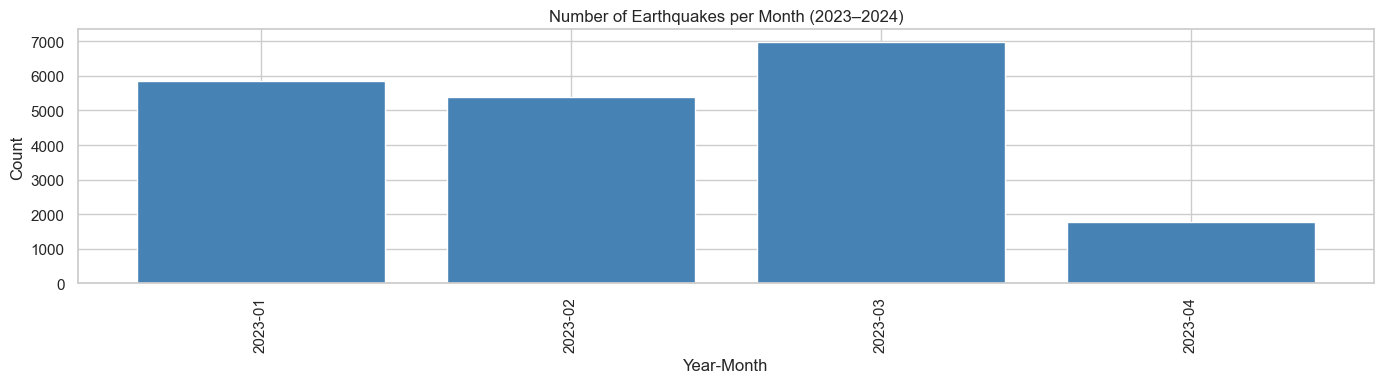

In [10]:
monthly = df.groupby(['year', 'month']).size().reset_index(name='count')
monthly['year_month'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 4))
plt.bar(monthly['year_month'], monthly['count'], color='steelblue')
plt.xticks(rotation=90)
plt.title('Number of Earthquakes per Month (2023–2024)')
plt.xlabel('Year-Month')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/earthquakes_per_month.png', dpi=150, bbox_inches='tight')
plt.show()